In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Zomato-data-.csv')
print(df.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [5]:
print(df.dtypes)

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object


In [7]:
df['rate'] = df['rate'].apply(lambda x: float(str(x).split('/')[0]))
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [8]:
print(df['rate'])

0      4.1
1      4.1
2      3.8
3      3.7
4      3.8
      ... 
143    3.3
144    3.3
145    4.0
146    3.0
147    3.9
Name: rate, Length: 148, dtype: float64


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB
None


In [10]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


Text(0.5, 0, 'Types of restaurant')

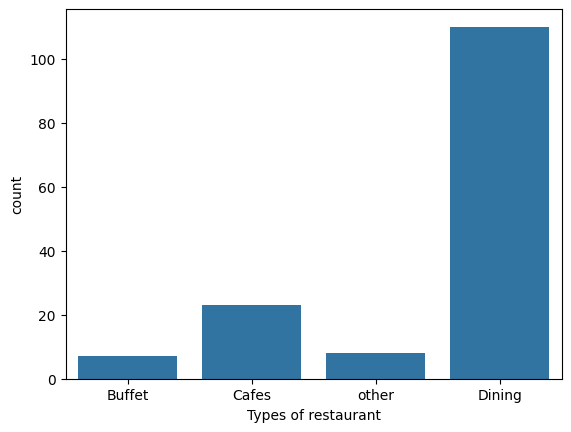

In [12]:
sns.countplot(x = df['listed_in(type)'])

plt.xlabel('Types of restaurant')

Text(0, 0.5, 'Votes')

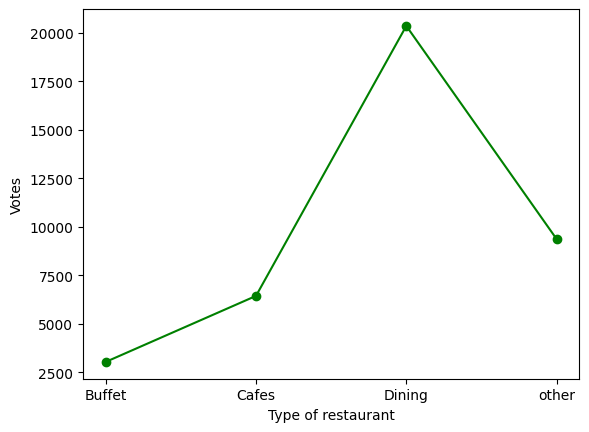

In [18]:
group_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': group_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

In [21]:
# Find the maximum number of votes
max_votes = df['votes'].max()

# Get the full row(s) where votes are equal to max_votes
max_row = df[df['votes'] == max_votes]

# Print the result
print("Maximum Votes:", max_votes)

print(max_row)


Maximum Votes: 4884
                 name online_order book_table  rate  votes  \
38  Empire Restaurant          Yes         No   4.4   4884   

    approx_cost(for two people) listed_in(type)  
38                          750           other  


Number of Customer Who dont have online order option : 90
Number of Customer Who have online order option : 58


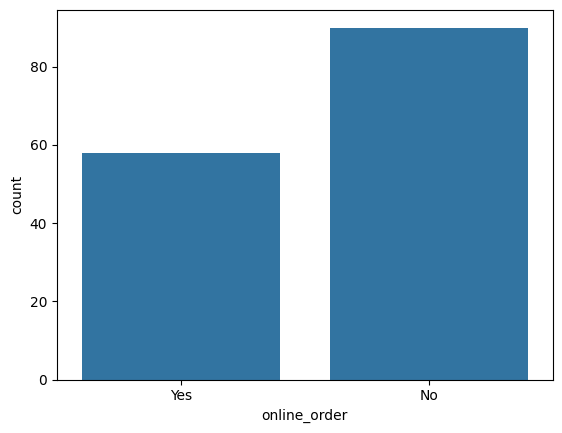

In [27]:
sns.countplot(x= df['online_order'])
count = df[df['online_order'] == 'No'].shape[0]
print("Number of Customer Who dont have online order option :",count)
count = df[df['online_order'] == 'Yes'].shape[0]
print("Number of Customer Who have online order option :",count)


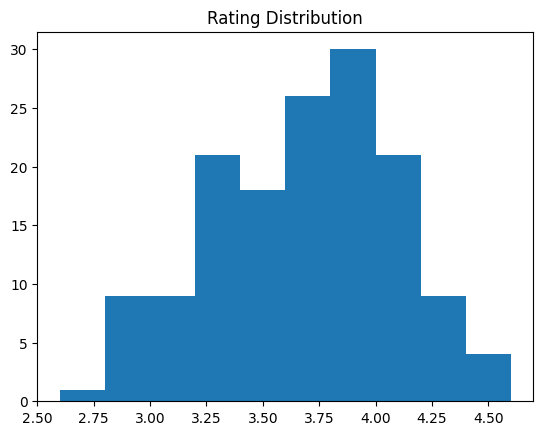

In [30]:
plt.hist(df['rate'])
plt.title ('Rating Distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

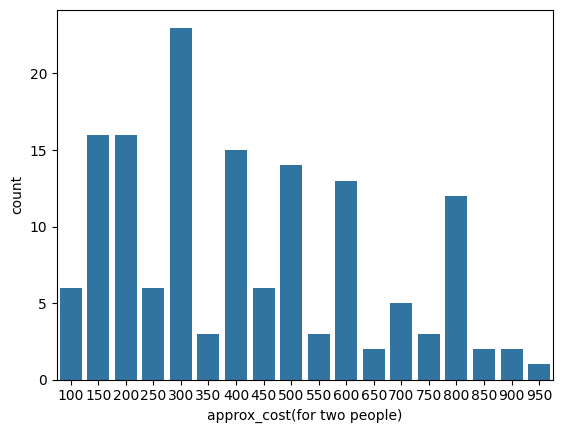

In [32]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x = couple_data)


Text(0, 0.5, 'Rate')

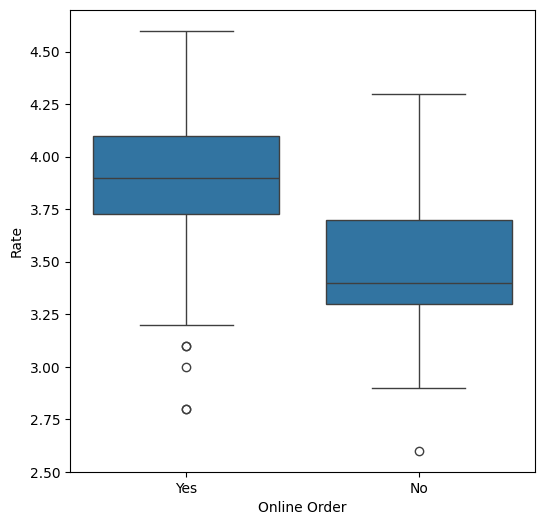

In [36]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)
plt.xlabel('Online Order')
plt.ylabel('Rate')



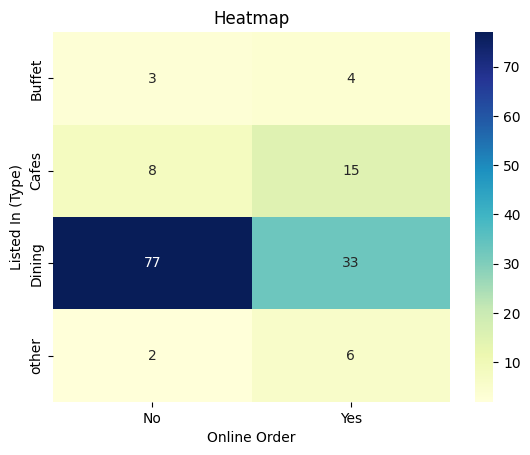

In [38]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

In [40]:
df.to_csv('Zomato-data-.csv', index=False)